# 02 — Taxonomic Distribution of SNIPE Homologues

**Runs locally** from cached data extracted in notebook 01.

This notebook analyzes the taxonomic distribution of SNIPE domain-bearing gene
clusters across the BERDL pangenome and characterizes their pangenome status
(core vs. accessory vs. singleton).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load extracted data from notebook 01
df_duf4041 = pd.read_csv(DATA_DIR / "duf4041_clusters.csv")
df_giy_species = pd.read_csv(DATA_DIR / "giy_yig_species.csv")
df_snipe = pd.read_csv(DATA_DIR / "snipe_both_domains.csv")
df_tax = pd.read_csv(DATA_DIR / "snipe_taxonomy.csv")

print(f"DUF4041 clusters: {len(df_duf4041)} across {df_duf4041['gtdb_species_clade_id'].nunique()} species")
print(f"GIY-YIG species:  {len(df_giy_species)} (from 1000-cluster sample)")
print(f"SNIPE (DUF4041):  {len(df_snipe)} clusters across {df_snipe['gtdb_species_clade_id'].nunique()} species")
print(f"Taxonomy:         {len(df_tax)} species")

DUF4041 clusters: 4572 across 1696 species
GIY-YIG species:  728 (from 1000-cluster sample)
SNIPE (DUF4041):  4572 clusters across 1696 species
Taxonomy:         1696 species


## Phylum-Level Distribution

In [ ]:
# Phylum distribution of SNIPE-bearing species
phylum_counts = df_tax.groupby('phylum')['gtdb_species_clade_id'].nunique().sort_values(ascending=False)
print(f"SNIPE detected in {len(phylum_counts)} phyla:")
print(phylum_counts.head(20))

# Plot top phyla
top_phyla = phylum_counts.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
top_phyla.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of species with SNIPE-like genes')
ax.set_ylabel('Phylum')
ax.set_title('SNIPE Homologue Distribution Across Bacterial Phyla\n(DUF4041 domain in gene clusters)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "snipe_phylum_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Core vs. Accessory Status

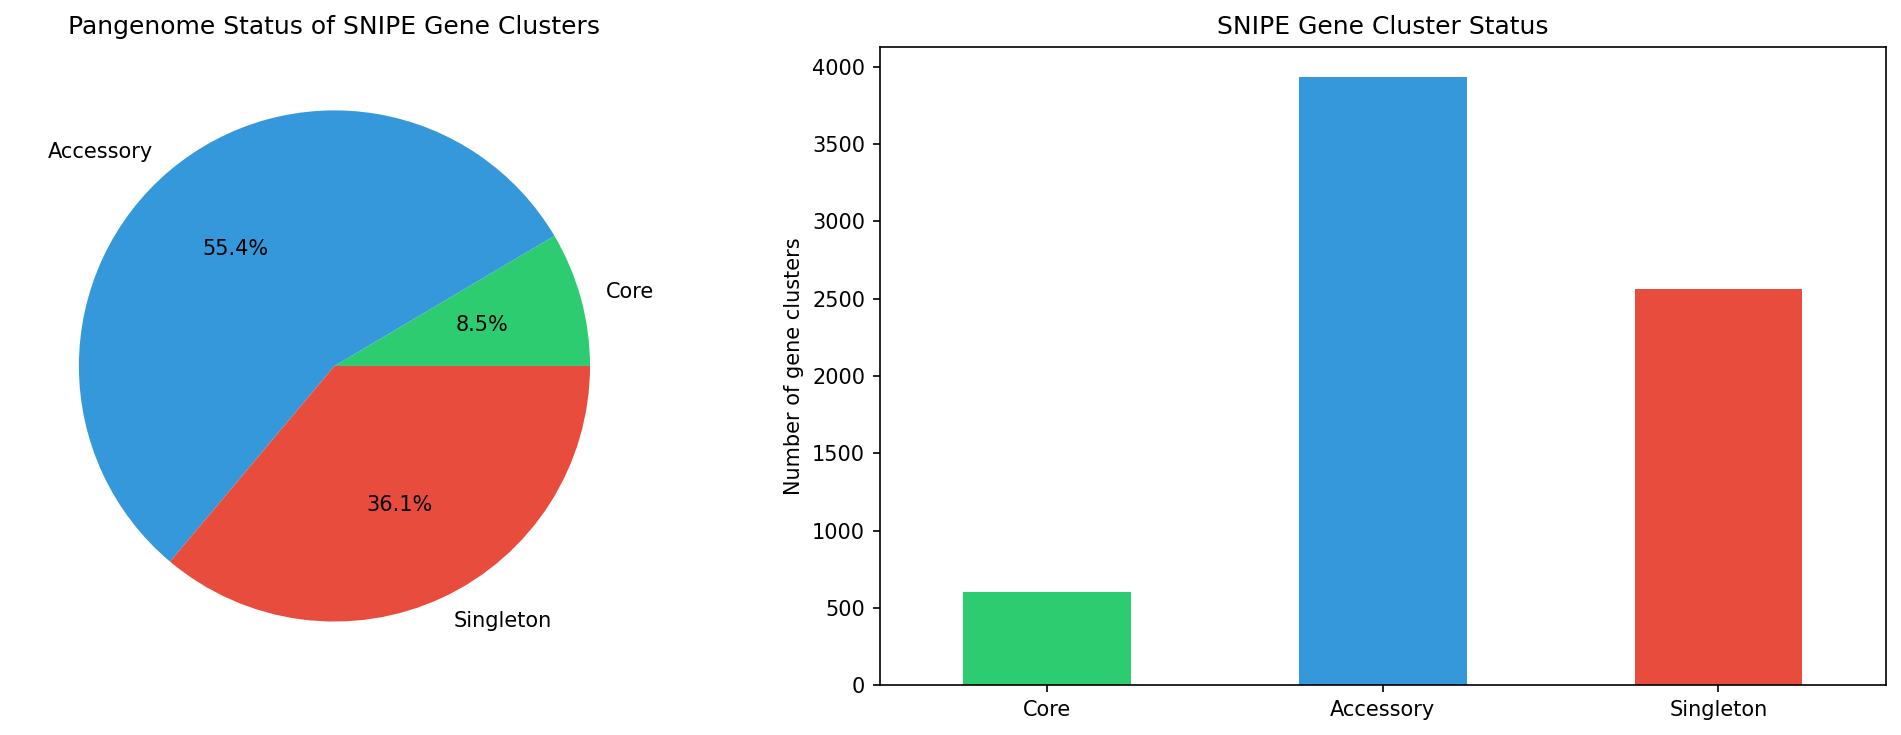


Pangenome status:
  Core: 604 (13.2%)
  Accessory: 3934 (86.0%)
  Singleton: 2566 (56.1%)


In [4]:
# Pangenome status of SNIPE gene clusters
for col in ['is_core', 'is_auxiliary', 'is_singleton']:
    df_snipe[col] = df_snipe[col].astype(str).str.lower().map({'true': True, 'false': False})

status_counts = pd.Series({
    'Core': df_snipe['is_core'].sum(),
    'Accessory': df_snipe['is_auxiliary'].sum(),
    'Singleton': df_snipe['is_singleton'].sum()
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Pangenome Status of SNIPE Gene Clusters')

# Bar chart
status_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_ylabel('Number of gene clusters')
axes[1].set_title('SNIPE Gene Cluster Status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "snipe_pangenome_status.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPangenome status:")
for status, count in status_counts.items():
    print(f"  {status}: {count} ({100*count/len(df_snipe):.1f}%)")

## DUF4041 vs GIY-YIG: Independent Domain Distributions

GIY-YIG is a widespread nuclease superfamily (also used in restriction enzymes
and DNA repair). How much larger is the GIY-YIG set compared to SNIPE-specific?

In [5]:
# Venn-style comparison
duf_species = set(df_duf4041['gtdb_species_clade_id'].dropna().unique())
giy_species = set(df_giy_species['gtdb_species_clade_id'].unique())
both_species = duf_species & giy_species

print(f"Species with DUF4041 only:      {len(duf_species - giy_species)}")
print(f"Species with GIY-YIG only:      {len(giy_species - duf_species)}")
print(f"Species with both (any cluster): {len(both_species)}")
print(f"")
print(f"Note: 'both' means the species has at least one cluster with DUF4041")
print(f"AND at least one with GIY-YIG — not necessarily in the same protein.")
print(f"DUF4041 and GIY-YIG never co-occur in the same eggNOG annotation (0 hits).")
print(f"")
print(f"DUF4041 is used as the primary SNIPE marker (2,962 clusters vs 74,686 GIY-YIG).")

Species with DUF4041 only:      1649
Species with GIY-YIG only:      681
Species with both (any cluster): 47

Note: 'both' means the species has at least one cluster with DUF4041
AND at least one with GIY-YIG — not necessarily in the same protein.
DUF4041 and GIY-YIG never co-occur in the same eggNOG annotation (0 hits).

DUF4041 is used as the primary SNIPE marker (2,962 clusters vs 74,686 GIY-YIG).


## Functional Description Analysis

In [6]:
# What are these genes annotated as?
print("Top functional descriptions for putative SNIPE genes:")
desc_counts = df_snipe['Description'].value_counts().head(15)
for desc, count in desc_counts.items():
    print(f"  {count:5d}  {desc}")

print(f"\nPreferred gene names:")
name_counts = df_snipe['Preferred_name'].dropna().value_counts().head(10)
for name, count in name_counts.items():
    print(f"  {count:5d}  {name}")

print(f"\nCOG categories:")
cog_counts = df_snipe['COG_category'].value_counts().head(10)
for cat, count in cog_counts.items():
    print(f"  {count:5d}  {cat}")

Top functional descriptions for putative SNIPE genes:
   2109  T5orf172
   1566  Domain of unknown function (DUF4041)
    319  Histidine kinase
    238  seryl-tRNA aminoacylation
    110  Psort location Cytoplasmic, score 7.50
    103  nuclear chromosome segregation
     54  Meiotically up-regulated gene 113
     28  T5orf172 domain-containing protein
     21  translation initiation factor activity
     20  Protein of unknown function (DUF1549)
      4  extracellular polysaccharide biosynthetic process

Preferred gene names:
   4442  -
    100  mobA_2
     26  algC
      4  tuaF

COG categories:
   1533  D
   1118  T
   1066  J
    834  M
     21  S


## Save Summary Tables

In [7]:
# Save phylum-level summary
phylum_summary = df_tax.groupby('phylum').agg(
    species_count=('gtdb_species_clade_id', 'nunique'),
    families=('family', 'nunique'),
    genera=('genus', 'nunique')
).sort_values('species_count', ascending=False)
phylum_summary.to_csv(DATA_DIR / "snipe_phylum_summary.csv")

print(f"Saved snipe_phylum_summary.csv ({len(phylum_summary)} phyla)")
phylum_summary.head(15)

Saved snipe_phylum_summary.csv (33 phyla)


,species_count,families,genera
phylum,,,
p__Pseudomonadota,556,54,183
p__Actinomycetota,334,30,105
p__Bacillota_A,275,28,151
p__Bacillota,206,37,83
p__Bacteroidota,114,32,61
p__Nitrospirota,45,2,12
p__Cyanobacteriota,28,13,22
p__Planctomycetota,22,10,18
p__Verrucomicrobiota,19,14,17
